## Terminology
**Epoch**: One forward pass and one backward pass of all the training example.

**Batch-size**: The number of training examples in one forward backward pass.

**Iteration**: Number of passes, each pass using [batch size] number of examples.

input data shape: torch.Size([768, 8]) target shape: torch.Size([768, 1])
epoch= 500, loss=0.4210, acc=0.8086
epoch=1000, loss=0.4064, acc=0.8125
epoch=1500, loss=0.3876, acc=0.8203
epoch=2000, loss=0.3796, acc=0.8268
epoch=2500, loss=0.3784, acc=0.8281
epoch=3000, loss=0.3785, acc=0.8203
epoch=3500, loss=0.3768, acc=0.8294
epoch=4000, loss=0.3771, acc=0.8255
epoch=4500, loss=0.3750, acc=0.8242
epoch=5000, loss=0.3729, acc=0.8281


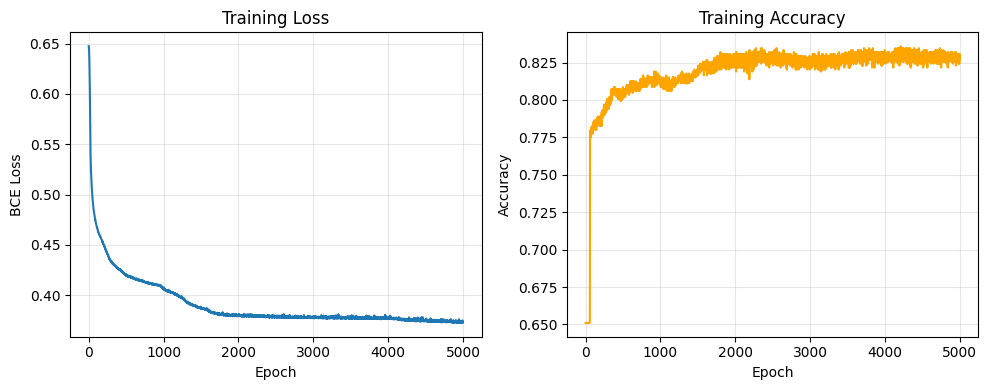

In [1]:
# How to define Dataset + DataLoader，并与 multiple_dimension_input 一致：下载、标准化、训练与可视化
import os
import urllib.request
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader


class DiabetesDataset(Dataset):
    def __init__(self, filepath):
        xy = np.loadtxt(filepath, delimiter=",", dtype=np.float32)
        self.len = xy.shape[0]  # 样本数
        x_np = xy[:, :-1]
        y_np = xy[:, [-1]]
        # 特征标准化（与 multiple_dimension_input 一致）
        mean = x_np.mean(axis=0)
        std = x_np.std(axis=0)
        x_np = (x_np - mean) / (std + 1e-7)
        self.x_data = torch.from_numpy(x_np)
        self.y_data = torch.from_numpy(y_np)

    def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

    def __len__(self):
        return self.len


# 优先本地 diabetes.csv，不存在则下载
data_path = "diabetes.csv"
if not os.path.exists(data_path):
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    urllib.request.urlretrieve(url, data_path)
    print(f"Downloaded dataset to: {data_path}")

dataset = DiabetesDataset(data_path)
print("input data shape:", dataset.x_data.shape, "target shape:", dataset.y_data.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
# notebook 下 num_workers=0 更稳；脚本里可改为 2
train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=(device.type == "cuda"),
    num_workers=0,
)


class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = torch.nn.Linear(8, 6)
        self.linear2 = torch.nn.Linear(6, 4)
        self.linear3 = torch.nn.Linear(4, 2)
        self.linear4 = torch.nn.Linear(2, 1)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.relu(self.linear3(x))
        x = self.linear4(x)  # logits
        return x


model = Model().to(device)
criterion = torch.nn.BCEWithLogitsLoss(reduction="mean")
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5000
loss_history = []
acc_history = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    epoch_correct = 0
    n_samples = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            pred_label = (logits >= 0).float()
            epoch_correct += (pred_label == batch_y).float().sum().item()
        epoch_loss += loss.item() * batch_x.size(0)
        n_samples += batch_y.size(0)

    avg_loss = epoch_loss / n_samples
    avg_acc = epoch_correct / n_samples
    loss_history.append(avg_loss)
    acc_history.append(avg_acc)

    if (epoch + 1) % 500 == 0:
        print(f"epoch={epoch+1:4d}, loss={avg_loss:.4f}, acc={avg_acc:.4f}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history, label="Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training Loss")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(acc_history, label="Accuracy", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## HOMEWORK、Kaggle-Titanic

### 0. 依赖和全局配置

In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# ---------- 随机种子 ----------
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# ---------- 训练超参数 ----------
batch_size = 64
num_epochs = 2000
learning_rate = 0.001

# device：有 GPU 用 cuda，否则 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


### 1. Dataset + DataLoader（数据准备）
目标：把 Kaggle Titanic 的表格数据，变成 PyTorch 能用的：
- 训练时：每次从 DataLoader 里取出一小批 x（特征） 和 y（是否幸存 0/1）。
- 预测时：对 测试集 只有 x，没有 y，所以 Dataset 只返回特征。

深度学习模型只吃**数字张量**，而原始 train.csv 里有英文、缺失、混合类型，所以要先**清洗 + 特征工程 + 编码 + 标准化**，再 torch.from_numpy 转成张量。

In [3]:
def _add_titanic_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    对每一行乘客，在原始列的基础上多加几列特征列，让模型能够更好的进行学习
    与 titanic_kaggle 一致：Title / FamilySize / IsAlone / Deck。
    """
    out = df.copy()    # 复制一份传进来的数据，避免在原数据上直接进行修改
    out["Title"] = out["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

    # 把稀有称谓合并为 Rare
    rare = {"Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"}
    out["Title"] = out["Title"].replace(rare, "Rare")

    # 把发育拼写统一成英文常见称谓，没有匹配到的填 Unknown
    out["Title"] = out["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    out["Title"] = out["Title"].fillna("Unknown")

    out["FamilySize"] = out["SibSp"] + out["Parch"] + 1
    out["IsAlone"] = (out["FamilySize"] == 1).astype(int)
    out["Deck"] = out["Cabin"].fillna("U").astype(str).str[0]
    return out


class TitanicTrainDataset(Dataset):
    """从 train.csv 构造 (x, y)。缺失值用训练集统计量填充；类别做 get_dummies；再按列标准化。"""

    # 连续数值型特征列，用于后续进行填充和标准化
    NUM_COLS = ["Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone"]
    # 类别型特征列，需要做独热编码
    CAT_COLS = ["Sex", "Embarked", "Title", "Deck"]

    def __init__(self, train_csv_path: str):
        df = pd.read_csv(train_csv_path)    # 读取训练集数据
        t = _add_titanic_features(df)    # 对读取到的训练集数据添加特征

        # 取出 t 数据框中的 "Survived" 列，转为 numpy 数组，类型变为 float32，并 reshape 成 (样本数, 1) 的二维数组，与后面 BCEWithLogitsLoss 里对 batch_y 的形状一致
        y = t["Survived"].values.astype(np.float32).reshape(-1, 1)

        # 1. 计算每个数值型特征列的中位数（用于缺失值填充）
        self._medians = {c: t[c].median() for c in self.NUM_COLS}
        # 2. 计算每个类别型特征列的最常出现的值（众数，用于缺失值填充，如果全为空则填空字符串）
        self._modes = {
            c: (t[c].mode().iloc[0] if len(t[c].mode()) > 0 else "")
            for c in self.CAT_COLS
        }

        # 3. 去掉不需要参与建模的列（去掉标签和无关列），得到特征数据框
        X_df = t.drop(columns=["Survived", "PassengerId", "Name", "Ticket", "Cabin"])
        # 4. 用中位数填充数值型特征的缺失值
        for c in self.NUM_COLS:
            X_df[c] = X_df[c].fillna(self._medians[c])
        # 5. 用众数填充类别型特征的缺失值
        for c in self.CAT_COLS:
            X_df[c] = X_df[c].fillna(self._modes[c])

        # 6. 对类别型特征做独热编码（one-hot，展成多个01列，不丢弃任何类别）
        X_cat = pd.get_dummies(X_df[self.CAT_COLS], drop_first=False)
        # 7. 记下独热编码后的所有列名，为后续测试集预处理对齐列顺序
        self.ref_cat_columns = X_cat.columns
        # 8. 数值型特征转为float32的二维numpy数组
        X_num = X_df[self.NUM_COLS].values.astype(np.float32)
        # 9. 拼接数值型特征和类别one-hot特征，得到最终的特征矩阵
        x_np = np.hstack([X_num, X_cat.values.astype(np.float32)])

        # 10. 按列计算均值和标准差（后续用于标准化）
        self._mean = x_np.mean(axis=0)
        self._std = x_np.std(axis=0) + 1e-7  # 加一个极小的数，防止除以0
        # 11. 特征标准化（zero mean, unit variance）
        x_np = (x_np - self._mean) / self._std

        # 12. 转成torch张量供后续模型/数据加载器使用
        self.x_data = torch.from_numpy(x_np)
        self.y_data = torch.from_numpy(y)
        self.len = len(df)  # 样本数
        self.in_features = x_np.shape[1]  # 输入特征维度

    def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

    def __len__(self):
        return self.len


class TitanicTestDataset(Dataset):
    """
    Titanic 测试集数据集类，用于 Kaggle Titanic 的 test.csv。
    test.csv 中没有 Survived 列。
    测试集的处理要和训练集严格一致，包括填充方式、独热编码类别、特征标准化的均值和方差，防止数据泄漏。
    """

    def __init__(self, test_csv_path: str, train_ds: TitanicTrainDataset):
        # 读取测试集 csv 文件
        df = pd.read_csv(test_csv_path)
        # 添加和训练集一致的衍生特征
        t = _add_titanic_features(df)

        # 去掉无关/不参与建模的特征（需和训练集保持一致）
        X_df = t.drop(columns=[c for c in ["PassengerId", "Name", "Ticket", "Cabin"] if c in t.columns])
        
        # 用训练集的中位数填充数值型特征的缺失值
        for c in train_ds.NUM_COLS:
            X_df[c] = X_df[c].fillna(train_ds._medians[c])
        # 用训练集的众数填充类别型特征的缺失值
        for c in train_ds.CAT_COLS:
            X_df[c] = X_df[c].fillna(train_ds._modes[c])

        # 对类别特征做独热编码（需和训练集的编码列严格对齐）
        X_cat = pd.get_dummies(X_df[train_ds.CAT_COLS], drop_first=False)
        X_cat = X_cat.reindex(columns=train_ds.ref_cat_columns, fill_value=0)  # 保证列顺序和训练集一致，多余缺失类别补0

        # 取出数值特征，转 float32
        X_num = X_df[train_ds.NUM_COLS].values.astype(np.float32)
        # 拼接数值特征和独热特征
        x_np = np.hstack([X_num, X_cat.values.astype(np.float32)])
        # 按训练集的均值和标准差做标准化（避免泄漏）
        x_np = (x_np - train_ds._mean) / train_ds._std

        # 转成 torch 张量，方便后续模型使用
        self.x_data = torch.from_numpy(x_np)
        # 保留 PassengerId 方便生成提交
        self.passenger_ids = torch.from_numpy(df["PassengerId"].values)
        # 样本数
        self.len = len(df)

    def __getitem__(self, index):
        return self.x_data[index]

    def __len__(self):
        return self.len


# 数据路径：与本 notebook 同目录下的 kaggle_titanic（可按你的实际位置修改）
DATA_DIR = "kaggle_titanic"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")

if not os.path.isfile(TRAIN_CSV):
    raise FileNotFoundError(
        f"未找到 {os.path.abspath(TRAIN_CSV)}，请将 Kaggle 下载的 train.csv 放到该路径。"
    )

train_dataset = TitanicTrainDataset(TRAIN_CSV)
# X: torch.Size([891, 26]) y: torch.Size([891, 1])，其中 891 是样本数，26 是特征数
print("X:", train_dataset.x_data.shape, "y:", train_dataset.y_data.shape, "in_features:", train_dataset.in_features)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=(device.type == "cuda"),
    num_workers=0,
)

# 需要预测提交时再使用（无标签，不参与训练）
if os.path.isfile(TEST_CSV):
    test_dataset = TitanicTestDataset(TEST_CSV, train_dataset)
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=(device.type == "cuda"),
        num_workers=0,
    )
    print("test X:", test_dataset.x_data.shape, "| test_loader 可用于 model.eval() 推理")
else:
    test_loader = None
    print("未找到 test.csv，已跳过 test_loader。")

X: torch.Size([891, 26]) y: torch.Size([891, 1]) in_features: 26
test X: torch.Size([418, 26]) | test_loader 可用于 model.eval() 推理


### 2. 模型设计

In [4]:
class Model(nn.Module):
    """全连接二分类：第一层输入维须等于 train_dataset.in_feature。"""

    def __init__(self, in_features: int, hidden1: int = 64, hidden2: int = 32, hidden3: int = 16):
        super().__init__()
        # 第一层线性层的输入维度要等于 train_dataset.in_features，前面得到 train_dataset.in_features = 26
        self.linear1 = nn.Linear(in_features, hidden1)
        self.linear2 = nn.Linear(hidden1, hidden2)
        self.linear3 = nn.Linear(hidden2, hidden3)
        self.linear4 = nn.Linear(hidden3, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.relu(self.linear3(x))
        x = self.linear4(x)  # logits，配 BCEWithLogitsLoss，此处不加 sigmoid
        return x


# 须先运行 Dataset 单元格得到 train_dataset
model = Model(train_dataset.in_features).to(device)
print("model 第一层输入维:", train_dataset.in_features)

model 第一层输入维: 26


### 3.损失函数与优化器

In [5]:
criterion = nn.BCEWithLogitsLoss(reduction="mean")
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

### 4.训练循环

In [6]:
loss_history = []    # 创建列表，记录每个 epoch 的损失值
acc_history = []    # 创建列表，记录每个 epoch 的准确率

for epoch in range(num_epochs):
    model.train()    # 设置模型为训练模式
    epoch_loss = 0.0    # 初始化每个 epoch 的损失值
    epoch_correct = 0    # 初始化每个 epoch 的正确样本数
    n_samples = 0    # 初始化每个 epoch 的样本数

    for batch_x, batch_y in train_loader:    # 遍历训练数据加载器中的每个批次
        batch_x = batch_x.to(device, non_blocking=True)    # 将批次数据移动到 GPU 或 CPU, non_blocking=True 表示异步操作
        batch_y = batch_y.to(device, non_blocking=True)    # 将批次标签移动到 GPU 或 CPU

        logits = model(batch_x)    # 前向传播，计算预测值
        loss = criterion(logits, batch_y)    # 使用预测值和真实值来计算损失

        optimizer.zero_grad()    # 梯度清零
        loss.backward()    # 反向传播，计算梯度
        optimizer.step()    # 更新模型参数

        with torch.no_grad():    # 计算准确率时不构建计算图，省显存
            # 二分类：sigmoid(logits)>=0.5 等价于 logits>=0，无需显式 sigmoid
            pred_label = (logits >= 0).float()
            epoch_correct += (pred_label == batch_y).float().sum().item()    # 计算正确样本数
        epoch_loss += loss.item() * batch_x.size(0)    # 累加损失值
        n_samples += batch_y.size(0)    # 累加样本数

    avg_loss = epoch_loss / n_samples    # 计算每个 epoch 的平均损失值
    avg_acc = epoch_correct / n_samples    # 计算每个 epoch 的平均准确率
    loss_history.append(avg_loss)    # 将平均损失值添加到损失历史列表中
    acc_history.append(avg_acc)    # 将平均准确率添加到准确率历史列表中

    if (epoch + 1) % 200 == 0:    # 每 200 个 epoch 打印一次损失和准确率
        print(f"epoch={epoch+1:4d}, loss={avg_loss:.4f}, acc={avg_acc:.4f}")

print("训练结束")

epoch= 200, loss=0.2433, acc=0.8945
epoch= 400, loss=0.2214, acc=0.9113
epoch= 600, loss=0.2101, acc=0.9102
epoch= 800, loss=0.2116, acc=0.9125
epoch=1000, loss=0.1862, acc=0.9226
epoch=1200, loss=0.1780, acc=0.9282
epoch=1400, loss=0.1711, acc=0.9293
epoch=1600, loss=0.1679, acc=0.9360
epoch=1800, loss=0.1630, acc=0.9371
epoch=2000, loss=0.1471, acc=0.9405
训练结束


### 5.可视化

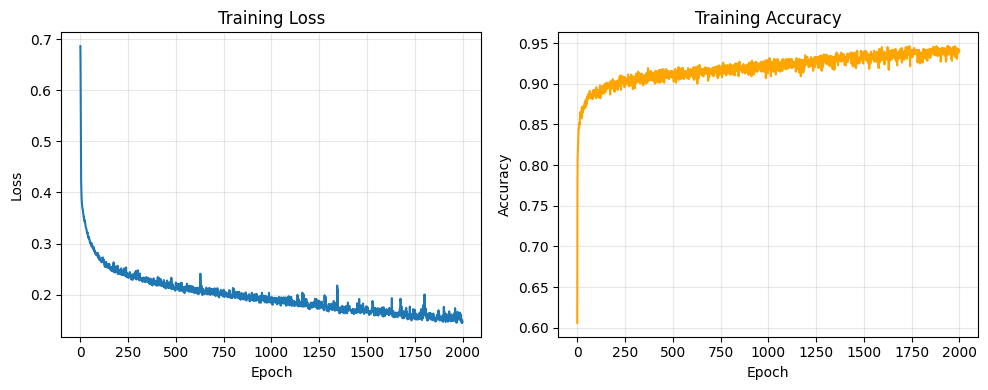

In [7]:
plt.figure(figsize=(10, 4))    
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(acc_history, color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6. 生成 Kaggle 提交文件

思路：
- 对 `test_loader` 做 `model.eval()` 推理；
- 将预测结果按 Kaggle 要求写成两列：`PassengerId, Survived`。

In [ ]:
if test_loader is None:
    raise RuntimeError("未找到 test.csv，无法生成 Kaggle 提交文件。")

model.eval()   # 设置模型为推理模式
all_preds = []    # 创建列表，记录每个 batch 的预测结果

with torch.no_grad():    # 推理时不需要构建计算图，节省显存
    for batch_x in test_loader:    # 遍历测试数据的每个批次
        batch_x = batch_x.to(device, non_blocking=True)    # 将批次数据移动到 GPU 上，non_blocking=True 表示异步操作
        logits = model(batch_x)    # 前向传播，计算预测值
        # 与训练时一致：logits >= 0 等价于 sigmoid(logits) >= 0.5
        pred = (logits >= 0).long().cpu().numpy().reshape(-1)    # 将预测值转化为numpy数组并展平为一维
        all_preds.append(pred)

preds = np.concatenate(all_preds, axis=0)    # 将所有预测结果拼接为一个一维数组
passenger_ids = test_dataset.passenger_ids.cpu().numpy().astype(int)    # 获取测试集的乘客ID

# 创建提交文件submission,包含乘客ID和预测的生存状态
submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": preds.astype(int),
})

# 可选：如果存在 sample_submission.csv，则对齐其 PassengerId 顺序
sample_submission_path = os.path.join(DATA_DIR, "sample_submission.csv")
if os.path.isfile(sample_submission_path):
    sample_sub = pd.read_csv(sample_submission_path)
    submission = sample_sub[["PassengerId"]].merge(submission, on="PassengerId", how="left")

output_path = os.path.join(DATA_DIR, "submission.csv")
submission.to_csv(output_path, index=False)    # 将预测结果保存为 CSV 文件

print(f"提交文件已生成: {os.path.abspath(output_path)}")
print(submission.head())
print("\nSurvived 分布:")
print(submission["Survived"].value_counts(dropna=False).sort_index())

提交文件已生成: /home/featurize/work/zzy/self_learning/pytorch_learning/kaggle_titanic/submission.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0

Survived 分布:
Survived
0    253
1    165
Name: count, dtype: int64
